# 01. What Is Numerical Analysis?

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. State the difference between a **problem** and an **algorithm**, and explain why that
   distinction is the backbone of the whole subject.
2. Explain why the answer a computer gives is almost never the exact answer, and why that
   is usually fine.
3. Derive **Horner's rule** for polynomial evaluation and count its operations.
4. Show that two algebraically identical formulas can differ in both **cost** and
   **accuracy**.
5. Read the three questions this course asks about every method: is it **right**, is it
   **fast**, and is it **stable**?

## Prerequisites

Calculus and basic linear algebra. Enough Python to read a `for` loop and a NumPy array.
Nothing else. This is lesson one.

---

## 1. What the subject actually is

Numerical analysis is the study of algorithms that produce approximate answers to
mathematical problems about **continuous** quantities, together with an honest account of
how wrong those answers are.

Three words in that sentence are doing the work.

**Approximate.** A computer holds finitely many numbers. The real line does not. So the
moment you write $\sqrt{2}$ or $\pi$ or $1/3$ into a machine, you have already made an
error. Numerical analysis is not about avoiding that error, which is impossible. It is
about controlling it and knowing its size.

**Algorithms.** Mathematics tells you that a solution exists. It often does not tell you
how to compute it in finite time. Cramer's rule solves a linear system exactly, and it is
completely useless for a system of 30 equations, as lesson 16 will show with an actual
timing. Existence and computability are different questions.

**Honest account.** This is the part that separates numerical analysis from just writing
code that produces numbers. Any program will produce numbers. The subject is about knowing
which digits of those numbers to believe.

## 2. Problem versus algorithm

This distinction runs through every lesson, so it is worth getting straight now.

> **Definition 1.1 (Problem).** A problem is a map $f : X \to Y$ from input data to an
> answer. "Given $A$ and $b$, find $x$ with $Ax = b$" is a problem. "Given $p$ and $x$,
> compute $p(x)$" is a problem.

> **Definition 1.2 (Algorithm).** An algorithm is a finite sequence of elementary
> operations that, run on a computer, produces an approximation $\hat{f}(x)$ to $f(x)$.

One problem has many algorithms. The problem does not change when you switch algorithms,
and neither does the true answer.

That gives us two independent sources of trouble, and they need different names:

| Question | Name | Property of |
|---|---|---|
| Is the true answer very sensitive to small changes in the input? | **Conditioning** | the **problem** |
| Does the algorithm add much more error than the problem forces? | **Stability** | the **algorithm** |

An ill-conditioned problem cannot be rescued by a better algorithm. An unstable algorithm
can ruin a perfectly well-conditioned problem. Confusing these two is the single most common
mistake in the field, and lesson 06 is devoted entirely to keeping them apart.

## 3. The three questions

For every method in this course we will ask exactly three things.

1. **Is it right?** Does it converge to the true answer, and how fast? This is where error
   analysis and order of convergence come in.
2. **Is it fast?** How does the work grow with the size of the problem? This is complexity,
   the subject of lesson 08.
3. **Is it stable?** In finite precision arithmetic, does the computed answer stay close to
   the true one? This is lesson 06 and everything after it.

A method can pass any two of these and fail the third. Classical Gram-Schmidt (lesson 29) is
right in exact arithmetic and fast, and unstable. Cramer's rule is right and stable and
absurdly slow. Bisection (lesson 09) is right, stable, and slow.

---

## 4. A first algorithm: evaluating a polynomial

Let us make all of this concrete with the smallest possible example.

The problem: given coefficients $a_0, \dots, a_n$ and a point $x$, compute

$$p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0.$$

This looks like it has nothing to teach. It has quite a lot.

### 4.1 The obvious algorithm

Read the formula literally: form each power $x^k$, multiply by its coefficient, add up.

Building $x^k$ from scratch by repeated multiplication costs $k-1$ multiplications, so the
powers cost

$$\sum_{k=0}^{n} \max(k - 1, 0) \quad\text{multiplications,}$$

then one more multiplication per term to apply the coefficient, and $n$ additions. The total
is on the order of $n^2/2$ multiplications. For degree 50 that is over 1300 operations.

### 4.2 Horner's rule

Now factor $x$ out repeatedly:

$$
\begin{aligned}
p(x) &= a_0 + a_1 x + a_2 x^2 + a_3 x^3 \\
     &= a_0 + x\left(a_1 + a_2 x + a_3 x^2\right) \\
     &= a_0 + x\left(a_1 + x\left(a_2 + a_3 x\right)\right).
\end{aligned}
$$

In general,

$$p(x) = a_0 + x\Big(a_1 + x\big(a_2 + \cdots + x(a_{n-1} + x a_n)\cdots\big)\Big).$$

This is **Horner's rule**, also called nested multiplication. Read from the inside out, each
step does one multiplication and one addition. There are $n$ steps.

> **Proposition 1.3.** Horner's rule evaluates a polynomial of degree $n$ using exactly $n$
> multiplications and $n$ additions.
>
> *Proof.* Induction on $n$. For $n = 0$ the value is $a_0$, using zero operations. Suppose
> the claim holds for degree $n-1$. Write $p(x) = a_0 + x \cdot q(x)$ where
> $q(x) = a_1 + a_2 x + \cdots + a_n x^{n-1}$ has degree $n - 1$. By hypothesis $q(x)$ costs
> $n-1$ multiplications and $n-1$ additions. Forming $a_0 + x q(x)$ adds exactly one
> multiplication and one addition. $\square$

That is a drop from about $n^2/2$ operations to $n$. Not a constant factor: a change in the
growth rate.

### 4.3 Pseudocode

```text
HORNER(a[0..n], x)
    # a is in descending order: a[0] is the coefficient of x^n
    result <- a[0]
    for i = 1 to n:
        result <- result * x + a[i]
    return result
```

Three lines. It is worth noticing that this is the same arithmetic as **synthetic division**,
and the same arithmetic as **converting a number from base b to decimal**. A number written
in base $b$ *is* a polynomial evaluated at $b$. Lesson 02 uses that fact directly.

## 5. Implementation and check

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
def horner_teaching(coeffs, x):
    """Horner's rule, written out so every step is visible.

    coeffs is in descending order: coeffs[0] multiplies the highest power.
    """
    result = coeffs[0]
    for a in coeffs[1:]:
        result = result * x + a
    return result


def naive_teaching(coeffs, x):
    """The literal reading of the formula, rebuilding each power from scratch."""
    n = len(coeffs) - 1
    total = 0.0
    for i, a in enumerate(coeffs):
        power = 1.0
        for _ in range(n - i):     # build x**(n-i) by repeated multiplication
            power = power * x
        total = total + a * power
    return total


# p(x) = 2x^3 - 6x^2 + 2x - 1, evaluated at x = 3
coeffs = [2, -6, 2, -1]
x = 3.0

print("Horner :", horner_teaching(coeffs, x))
print("naive  :", naive_teaching(coeffs, x))
print("numpy  :", np.polyval(coeffs, x))
print("by hand: 2*27 - 6*9 + 2*3 - 1 =", 2*27 - 6*9 + 2*3 - 1)

Horner : 5.0
naive  : 5.0
numpy  : 5.0
by hand: 2*27 - 6*9 + 2*3 - 1 = 5


All four agree. That is the first check of the course, and the pattern will repeat in every
lesson: **write it yourself, then confirm against something you trust.**

The library version lives in `nalib.polynomials`. Let us confirm the teaching version and the
library version agree across many random inputs, not just one.

In [3]:
from nalib import polynomials as poly

rng_local = np.random.default_rng(SEED)
worst = 0.0
for _ in range(2000):
    deg = int(rng_local.integers(1, 12))
    c = rng_local.standard_normal(deg + 1)
    xs = rng_local.standard_normal()
    a = horner_teaching(list(c), xs)
    b = poly.horner(c, xs)
    d = np.polyval(c, xs)
    worst = max(worst, abs(a - b), abs(float(b) - d))

print(f"worst disagreement over 2000 random polynomials: {worst:.3e}")
assert worst == 0.0, "the three implementations should agree bit for bit"
print("teaching version, nalib version and numpy.polyval agree exactly")

worst disagreement over 2000 random polynomials: 0.000e+00
teaching version, nalib version and numpy.polyval agree exactly


They agree *bit for bit*, not just to within a tolerance. That is expected: all three perform
the identical sequence of floating point operations, and floating point arithmetic is
deterministic. Getting exactly zero here is a stronger check than getting something small.

## 6. Counting the operations for real

We claimed $n$ operations for Horner and about $n^2/2$ for the naive version. Claims are
cheap. `nalib.cost` provides a counter that wraps a number and records every arithmetic
operation performed on it, so we can measure the counts instead of trusting the derivation.

In [4]:
from nalib import cost

degrees = [2, 5, 10, 20, 50, 100]
rows = []
for n in degrees:
    c = [1.0] * (n + 1)
    _, ch = cost.count_ops(lambda t: poly.horner_scalar(c, t), 1.1)
    _, cn = cost.count_ops(lambda t: poly.naive_scalar(c, t), 1.1)
    rows.append((n, ch.adds, ch.muls, cn.adds, cn.muls))

print(f"{'degree':>7}  {'Horner adds':>12} {'Horner muls':>12}   "
      f"{'naive adds':>11} {'naive muls':>11}")
print("-" * 62)
for n, ha, hm, na, nm in rows:
    print(f"{n:>7}  {ha:>12} {hm:>12}   {na:>11} {nm:>11}")

 degree   Horner adds  Horner muls    naive adds  naive muls
--------------------------------------------------------------
      2             2            2             3           5
      5             5            5             6          20
     10            10           10            11          65
     20            20           20            21         230
     50            50           50            51        1325
    100           100          100           101        5150


Now check the measured counts against the formulas we derived.

In [5]:
for n, ha, hm, na, nm in rows:
    pred_h = poly.flop_count_horner(n)      # (adds, muls)
    pred_n = poly.flop_count_naive(n)
    assert (ha, hm) == pred_h, (n, (ha, hm), pred_h)
    assert (na, nm) == pred_n, (n, (na, nm), pred_n)

print("every measured operation count matches the derived formula exactly")
print(f"at degree 100: Horner uses {rows[-1][2]} multiplications, "
      f"naive uses {rows[-1][4]}")
print(f"that is a factor of {rows[-1][4] / rows[-1][2]:.1f}")

every measured operation count matches the derived formula exactly
at degree 100: Horner uses 100 multiplications, naive uses 5150
that is a factor of 51.5


The derivation and the measurement agree exactly. This is the standard we will hold every
complexity claim to.

## 7. Visualising the growth

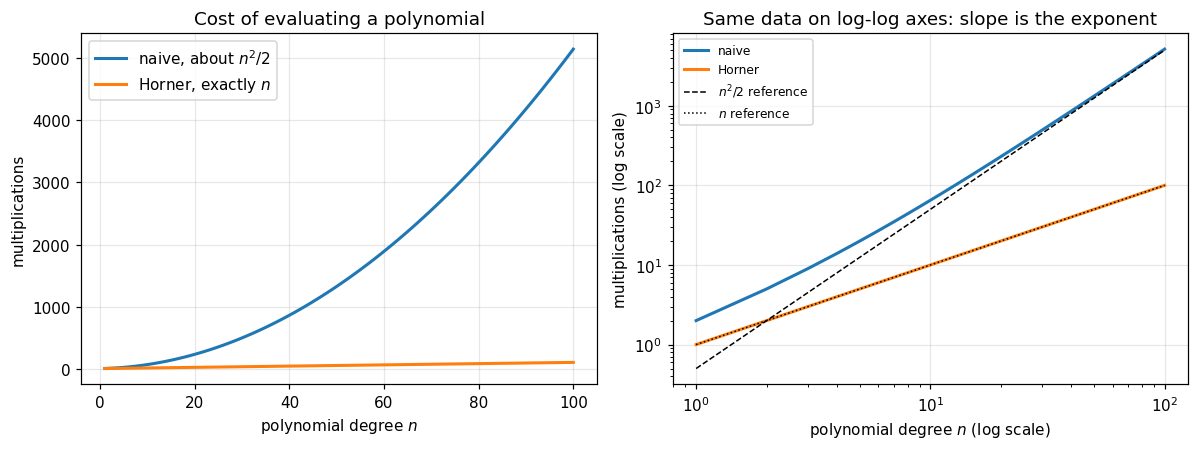

In [6]:
ns = np.arange(1, 101)
horner_muls = np.array([poly.flop_count_horner(int(n))[1] for n in ns])
naive_muls = np.array([poly.flop_count_naive(int(n))[1] for n in ns])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(ns, naive_muls, label="naive, about $n^2/2$", lw=2)
ax1.plot(ns, horner_muls, label="Horner, exactly $n$", lw=2)
ax1.set_xlabel("polynomial degree $n$")
ax1.set_ylabel("multiplications")
ax1.set_title("Cost of evaluating a polynomial")
ax1.legend()

ax2.loglog(ns, naive_muls, label="naive", lw=2)
ax2.loglog(ns, horner_muls, label="Horner", lw=2)
ax2.loglog(ns, ns.astype(float)**2 / 2, "k--", lw=1, label="$n^2/2$ reference")
ax2.loglog(ns, ns.astype(float), "k:", lw=1, label="$n$ reference")
ax2.set_xlabel("polynomial degree $n$ (log scale)")
ax2.set_ylabel("multiplications (log scale)")
ax2.set_title("Same data on log-log axes: slope is the exponent")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

**What to take from this.** On the left the gap looks dramatic but you cannot read the growth
rate off it. On the right, a straight line on log-log axes means a power law, and its *slope*
is the exponent. The naive line has slope 2, Horner's has slope 1. Log-log plots are the
standard tool for reading off a rate, and we will use them constantly.

## 8. It is not only about speed

Here is the part people miss. Horner's rule is not just cheaper. On badly behaved
polynomials it is also **more accurate**, because it performs fewer operations and each
operation is a chance to round.

The polynomial $(x-1)^6$, expanded out, is a classic test. Near $x = 1$ its value is
minuscule, but the individual terms in the expanded form are of size 1. Adding numbers of
size 1 to get an answer of size $10^{-14}$ means almost every digit cancels. That is
**catastrophic cancellation**, and lesson 05 is devoted to it.

In [7]:
# (x-1)^6 expanded: x^6 - 6x^5 + 15x^4 - 20x^3 + 15x^2 - 6x + 1
expanded = [1.0, -6.0, 15.0, -20.0, 15.0, -6.0, 1.0]
xs = np.linspace(0.998, 1.002, 601)

exact = (xs - 1.0) ** 6                       # the stable, factored form
by_horner = poly.horner(expanded, xs)         # nested form
by_naive = np.array([poly.naive_scalar(expanded, float(t)) for t in xs])

peak = np.max(exact)
err_h = np.max(np.abs(by_horner - exact))
err_n = np.max(np.abs(by_naive - exact))

print(f"largest true value anywhere on this interval : {peak:.3e}")
print(f"worst error, Horner on the expanded form     : {err_h:.3e}  "
      f"({err_h / peak:.0f}x the true peak)")
print(f"worst error, naive on the expanded form      : {err_n:.3e}  "
      f"({err_n / peak:.0f}x the true peak)")

largest true value anywhere on this interval : 6.400e-17
worst error, Horner on the expanded form     : 2.998e-15  (47x the true peak)
worst error, naive on the expanded form      : 5.329e-15  (83x the true peak)


The error is not a small perturbation. It is **tens of times larger than the largest value
the function takes anywhere on the interval**. The computed curve carries no information
about the true one at all.

There is an even blunter way to see that the answers are wrong. A real number raised to the
sixth power cannot be negative:

In [8]:
print(f"most negative value computed by Horner : {by_horner.min():.3e}")
print(f"most negative value computed naively   : {by_naive.min():.3e}")

assert (exact >= 0).all(), "the true sixth power is never negative"
assert by_horner.min() < 0, "expanded form should produce impossible negative values"
assert by_naive.min() < 0, "expanded form should produce impossible negative values"
assert err_h > 10 * peak and err_n > 10 * peak
print("\nboth expanded evaluations report negative values for a sixth power,")
print("which is impossible. every digit they produce is roundoff noise.")

most negative value computed by Horner : -2.887e-15
most negative value computed naively   : -5.329e-15

both expanded evaluations report negative values for a sixth power,
which is impossible. every digit they produce is roundoff noise.


This is a **deliberate failure**, set up on purpose. The assertions above encode what we
expect to go wrong, so if the behaviour ever changed the lesson would stop building. Now look
at the shape of what these methods compute.

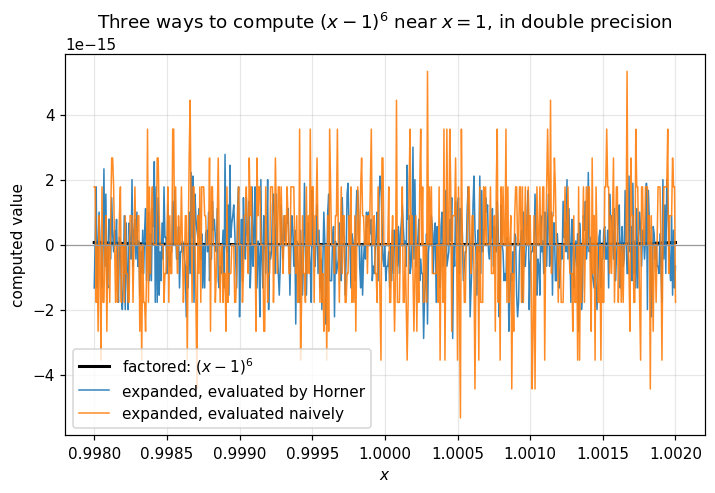

In [9]:
fig, ax = plt.subplots()
ax.plot(xs, exact, "k-", lw=2, label=r"factored: $(x-1)^6$")
ax.plot(xs, by_horner, lw=1, alpha=0.9, label="expanded, evaluated by Horner")
ax.plot(xs, by_naive, lw=1, alpha=0.9, label="expanded, evaluated naively")
ax.set_xlabel("$x$")
ax.set_ylabel("computed value")
ax.set_title(r"Three ways to compute $(x-1)^6$ near $x=1$, in double precision")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.legend()
plt.show()

**What to take from this.** The black curve, barely distinguishable from zero at this scale,
is what the function actually does. The other two are what the computer reports: jagged noise
swinging above and below zero, tens of times larger than the true values. The polynomial is
the same polynomial in all three cases. Only the *arrangement of the arithmetic* differs.

This is the whole subject in one picture. The mathematics did not change. The algorithm did,
and the answer fell apart.

Two conclusions worth separating carefully:

- The expanded form is a **badly conditioned way to represent this problem** near $x = 1$.
  No evaluation algorithm fixes that.
- Given the expanded form, Horner is the **better algorithm**, but it cannot undo the damage
  the representation already did.

Problem versus algorithm again, and we are only in lesson 01.

## 9. Complexity

| Algorithm | Multiplications | Additions | Memory |
|---|---|---|---|
| Naive, recomputing powers | $\tfrac{n(n+1)}{2} + n$ | $n + 1$ | $O(1)$ |
| Naive, reusing powers | $2n$ | $n$ | $O(1)$ |
| Horner | $n$ | $n$ | $O(1)$ |

All three use constant extra memory. Only the arithmetic differs.

Horner is **optimal** in a precise sense: no algorithm can evaluate a general degree-$n$
polynomial in fewer than $n$ multiplications, a result of Ostrowski for multiplications and
Pan for additions. So this is not just a good method, it is the end of the story for this
problem.

*(That optimality result is background context, not from the course sources.)*

## 10. Applications

Nested evaluation shows up far beyond polynomials:

- **Number base conversion** (lesson 02): reading digits left to right is Horner at the base.
- **Newton's method on polynomials** (lesson 13): value and derivative in one nested pass.
- **Interpolation** (lessons 43 and 44): the Newton form of an interpolating polynomial is
  evaluated by exactly this nesting.
- **Continued fractions and rational approximation** (lesson 56).
- **Neural network layers**: a stack of affine maps composed in sequence is nested evaluation
  with matrices instead of scalars.

## 11. Common mistakes

1. **Thinking a small residual means a correct answer.** It does not. Lesson 18 gives a
   linear system where the residual is tiny and the answer is wrong in the first digit.
2. **Blaming the algorithm for an ill-conditioned problem.** Section 8 above: the expanded
   $(x-1)^6$ is hopeless near $x=1$ no matter how you evaluate it.
3. **Optimising operation counts and ignoring accuracy.** Or the reverse. Both matter, and
   they sometimes pull in opposite directions.
4. **Believing printed digits.** Python will happily print 17 digits of a number that is
   correct to 3. Knowing which are real is the point of lesson 04.

## 12. Exercises

**Level 1, conceptual**

1.1 State in your own words the difference between conditioning and stability. Give one
example of each from this lesson.

1.2 Why is "the algorithm gave an answer with a small residual" not the same as "the
algorithm gave a correct answer"?

**Level 2, mathematical**

2.1 Prove that evaluating $x^n$ by repeated squaring costs $O(\log n)$ multiplications, not
$n-1$. Write out the method for $n = 100$.

2.2 Horner's rule needs $n$ multiplications. Show that for the specific polynomial
$p(x) = x^n$, only $O(\log n)$ are needed. Does this contradict the optimality claim in
section 9? Explain.

2.3 Derive the operation count for the naive algorithm that computes the powers
*incrementally* (keeping the running value of $x^k$ instead of rebuilding it). Confirm it is
$2n$ multiplications.

**Level 3, computational**

3.1 Implement the incremental-powers version described in 2.3. Verify its operation count
with `nalib.cost.count_ops` and confirm it matches your derivation.

3.2 Implement `horner_with_derivative`, returning both $p(x)$ and $p'(x)$ from one pass.
Check it against `numpy.polyval` applied to `numpy.polyder`. The version in
`nalib.polynomials` is one answer, so write yours first.

**Level 4, experimental**

4.1 Repeat the $(x-1)^6$ experiment with exponents 2, 4, 6, 8 and 10. Plot the worst error
against the exponent on a log scale. What is the growth rate, and can you explain it?

4.2 Time `horner` against `naive_eval` for degrees from 10 to 2000. Fit the exponent with
`nalib.cost.fit_exponent`. Do the measured exponents match 1 and 2? If not, at what degree do
they start to?

**Level 5, advanced**

5.1 The factored form $(x-1)^6$ is accurate and the expanded form is not. Is there a
representation that is accurate *and* lets you read off the coefficients? Investigate what
happens if you evaluate in the Newton form centred at $x = 1$. Relate this to lesson 43.

5.2 Estimate the relative error in Horner's rule from the standard model
$\mathrm{fl}(a \circ b) = (a \circ b)(1 + \delta)$ with $|\delta| \le u$. Show that the
computed value is the exact value of a polynomial with slightly perturbed coefficients, and
find how much they are perturbed. This is a **backward error** result, and it is the reason
Horner is called backward stable. Compare with lesson 06.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 13. Key takeaways

- A **problem** is a map from data to answer. An **algorithm** is a finite recipe that
  approximates it. They fail in different ways and need different words: **conditioning** for
  the problem, **stability** for the algorithm.
- Every method gets three questions: is it right, is it fast, is it stable.
- **Horner's rule** evaluates a degree-$n$ polynomial in $n$ multiplications and $n$
  additions, down from about $n^2/2$, and it is provably optimal.
- Rearranging arithmetic that is algebraically identical changes both the cost and the
  accuracy. The $(x-1)^6$ experiment shows the accuracy collapsing entirely.
- Always verify: write it yourself, then check against a trusted library **and** against the
  defining identity.

## Where this goes next

Lesson 02 takes the fact that a number in base $b$ is a polynomial evaluated at $b$ and uses
it to build the representation of numbers inside a computer. Lesson 03 turns that into IEEE
754 floating point, and lesson 05 returns to the cancellation we just saw and explains
exactly when it happens.

---

*Sources: this lesson draws on Sauer, Numerical Analysis 3rd ed., section 0.1 and the
introductory framing of chapter 0; and Gupta, Numerical Methods, appendices A, B and D. The
optimality of Horner's rule is supplementary background and is not from either source book.*